# Dependencias

In [127]:
!python -m pip install -r requirements.txt
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as rot
import time as t

## Cargar Imagenes

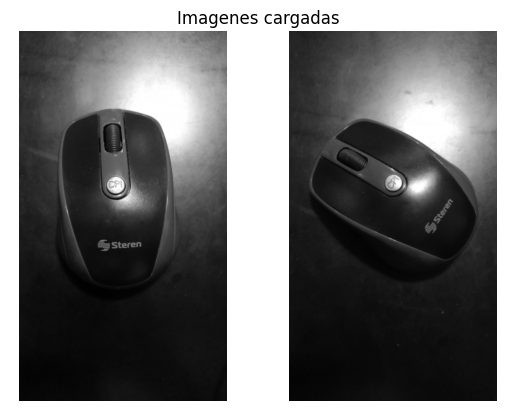

In [115]:
img1 = cv.imread("../media/imagen1.jpeg", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("../media/imagen2.jpeg", cv.IMREAD_GRAYSCALE)

img1_col = cv.imread("../media/imagen1.jpeg")
img2_col = cv.imread("../media/imagen2.jpeg")

plt.title("Imagenes cargadas")
plt.axis("off")
plt.subplot(1,2,1)
plt.axis("off")
plt.imshow(img1, "gray")
plt.subplot(1,2,2)
plt.axis("off")
plt.imshow(img2, "gray")
plt.show()

## Keypoints y Descriptores de las Imagenes

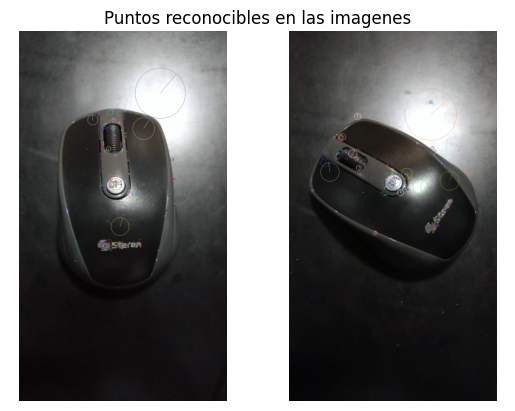

In [116]:
sift = cv.SIFT_create()

plt.title("Puntos reconocibles en las imagenes")
plt.axis("off")

kp_1, dsc_1 = sift.detectAndCompute(img1, None)
img_kp = cv.drawKeypoints(img1_col, kp_1, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.subplot(1, 2, 1)
plt.imshow(img_kp)
plt.axis("off")

kp_2, dsc_2 = sift.detectAndCompute(img2, None)
img_kp = cv.drawKeypoints(img2_col, kp_2, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.subplot(1, 2, 2)
plt.imshow(img_kp)
plt.axis("off")

plt.show()

## 1. Feature Matching con BFMatcher

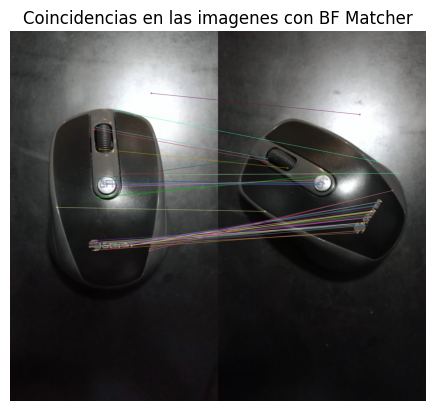

In [138]:
bf = cv.BFMatcher_create()

s_bf = t.time()
matches_bf = bf.knnMatch(dsc_1, dsc_2, k=2)
time_bv = t.time() - s_bf

good_matches_bf = [m for m, n in matches_bf if m.distance < 0.7 * n.distance]

img_matches = cv.drawMatches(
    img1_col, kp_1,
    img2_col, kp_2,
    good_matches_bf,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img_matches)
plt.title("Coincidencias en las imagenes con BF Matcher")
plt.axis("off")
plt.show()

## 2. Feature Matching con FLANN

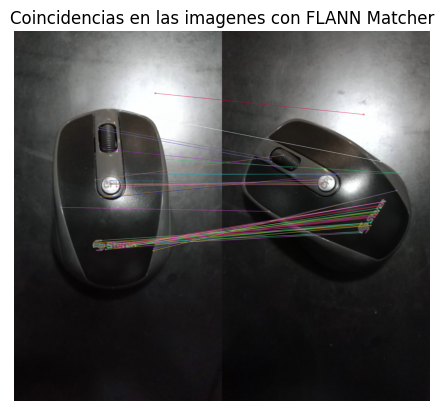

In [137]:
flann = cv.FlannBasedMatcher_create()

s_fl = t.time()
matches_fl = flann.knnMatch(dsc_1, dsc_2, k=2)
time_fl = t.time() - s_fl

good_matches_fl = [m for m, n in matches_fl if m.distance < 0.7 * n.distance]

img_matches = cv.drawMatches(
    img1_col, kp_1,
    img2_col, kp_2,
    good_matches_fl,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img_matches)
plt.title("Coincidencias en las imagenes con FLANN Matcher")
plt.axis("off")
plt.show()

## 3. Cálculo de Homografía

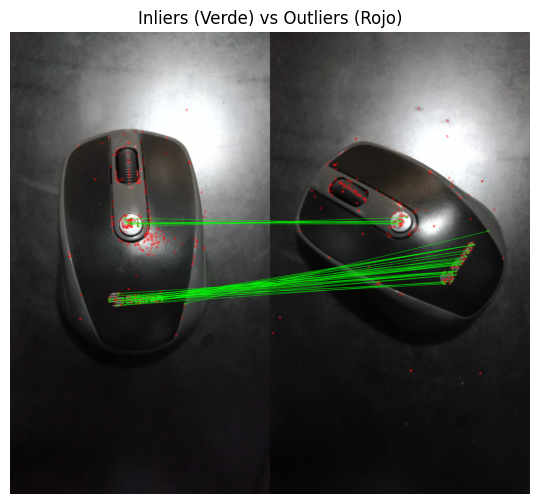

Matriz de transformación proyectiva: 
[[ 9.06040760e-01  9.33974725e-01 -4.60472270e+02]
 [-6.46401923e-01  7.93788323e-01  5.25077037e+02]
 [ 3.14897157e-04  9.39846197e-05  1.00000000e+00]]
Rotación: 
Z: -48.16747334344905, Y: -1.5189003303590585, X: 7.645860042364803
Traslación: 
X: -0.03127935360143601, Y: -0.09222394675791133, Z: 0.46443815534271193


In [ ]:
src_pts = np.float32([kp_1[m.queryIdx].pt for m in good_matches_fl]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_2[m.trainIdx].pt for m in good_matches_fl]).reshape(-1, 1, 2)

H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5)

mask_flat = mask.ravel().tolist()
inlier_matches = [m for m, is_inlier in zip(good_matches_fl, mask_flat) if is_inlier]


img_matches = cv.drawMatches(
    img1_col, kp_1,
    img2_col, kp_2,
    good_matches_fl, None,
    matchColor=(0, 255, 0),
    singlePointColor=(255, 0, 0),
    matchesMask=mask_flat,
    flags=cv.DrawMatchesFlags_DEFAULT
)

plt.figure(figsize=(12, 6))
plt.imshow(img_matches)
plt.title('Inliers (Verde) vs Outliers (Rojo)')
plt.axis('off')
plt.show()

H = H / H[2, 2]

print("Matriz de transformación proyectiva: ")
print(H)
num_solutions, rotations, translations, normals = cv.decomposeHomographyMat(H, np.float32([
    [1.24953842e+03, 0.00000000e+00, 6.41007951e+02],
    [0.00000000e+00, 1.17797383e+03, 6.85636048e+02],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
]))

print("Rotación: ")
deg = np.degrees(rot.from_matrix(rotations[0]).as_euler("zyx"))
print(*map(lambda x,y: f"{y}: {x}", deg, "ZYX"), sep=", ")
print("Traslación: ")
print(*map(lambda x,y: f"{y}: {x[0]}", translations[0], "XYZ"), sep=", ")

## 4. Detección de Objetos

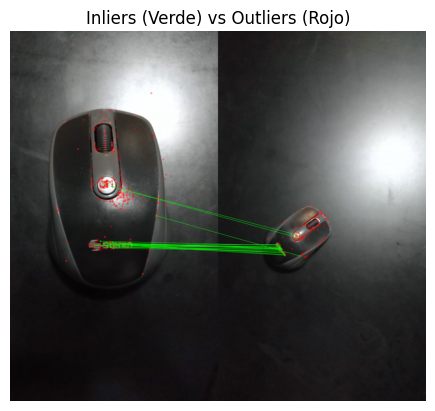

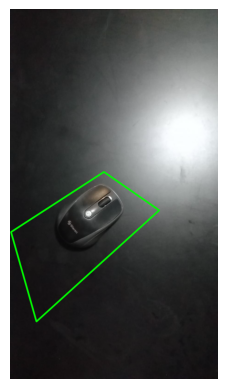

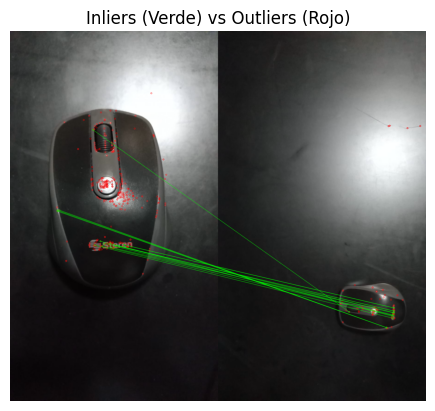

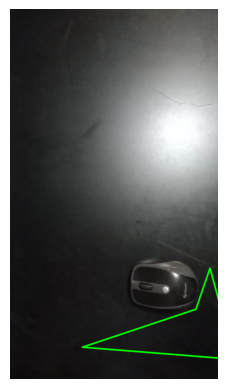

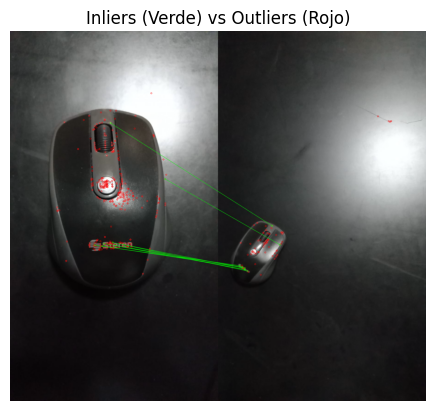

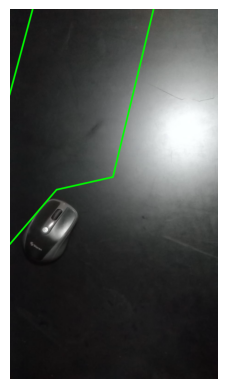

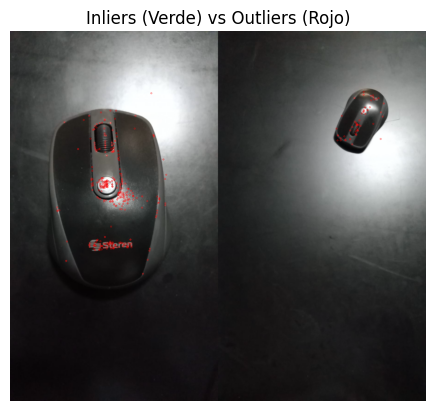

No se encontró el objeto


In [149]:
escenas = [
    "../media/escena1.jpeg",
    "../media/escena2.jpeg",
    "../media/escena3.jpeg",
    "../media/escena4.jpeg"
]
for i, path in enumerate(escenas, 1):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    img_col = cv.imread(path)
    kp, dsc = sift.detectAndCompute(img, None)
    matches = flann.knnMatch(dsc_1, dsc, k=2)
    good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]
    src_pts = np.float32([kp_1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5)
    
    mask_flat = mask.ravel().tolist()
    inlier_matches = [m for m, is_inlier in zip(good_matches, mask_flat) if is_inlier]

    img_matches = cv.drawMatches(
        img1_col, kp_1,
        img_col, kp,
        good_matches, None,
        matchColor=(0, 255, 0),
        singlePointColor=(255, 0, 0),
        matchesMask=mask_flat,
        flags=cv.DrawMatchesFlags_DEFAULT
    )

    plt.imshow(img_matches)
    plt.title('Inliers (Verde) vs Outliers (Rojo)')
    plt.axis('off')
    plt.show()
    
    if H is None:
        print("No se encontró el objeto")
    else:
        h, w = img1.shape[:2]

        obj_corners = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)

        corners = cv.perspectiveTransform(obj_corners, H)

        res = img_col.copy()
        res = cv.polylines(res, [np.int32(corners)], True, (0, 255, 0), 5, cv.LINE_AA)

        plt.imshow(res)
        plt.axis('off')
        plt.show()

## 5. Image Stitching

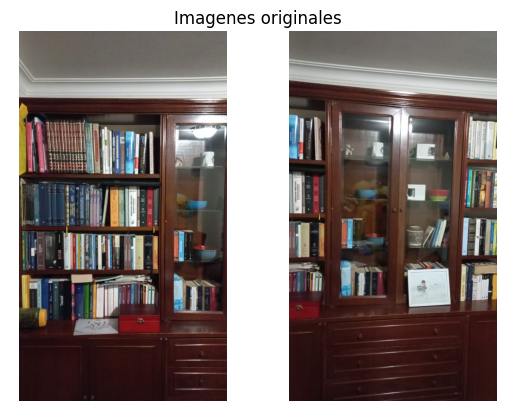

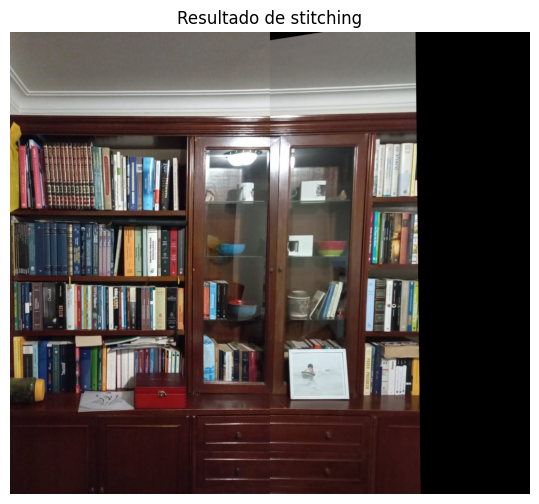

In [ ]:
img_l = cv.imread('../media/img_pan1.jpeg', cv.IMREAD_COLOR_RGB)
img_r = cv.imread('../media/img_pan2.jpeg', cv.IMREAD_COLOR_RGB)

plt.title("Imagenes originales")
plt.axis("off")
plt.subplot(1,2,1)
plt.imshow(img_l)
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(img_r)
plt.axis("off")
plt.show()

grey_l = cv.cvtColor(img_l, cv.COLOR_BGR2GRAY)
grey_r = cv.cvtColor(img_r, cv.COLOR_BGR2GRAY)

kp_l, des_l = sift.detectAndCompute(grey_l, None)
kp_r, des_r = sift.detectAndCompute(grey_r, None)

matches_fl = flann.knnMatch(des_l, des_r, k=2)
good_matches_fl = [m for m, n in matches_fl if m.distance < 0.7 * n.distance]

pts_l = np.float32([kp_l[m.queryIdx].pt for m in good_matches_fl]).reshape(-1, 1, 2)
pts_r = np.float32([kp_r[m.trainIdx].pt for m in good_matches_fl]).reshape(-1, 1, 2)

H, _ = cv.findHomography(pts_r, pts_l, cv.RANSAC, 5.0)

width = img_l.shape[1] + img_r.shape[1]
height = max(img_l.shape[0], img_r.shape[0])

res = cv.warpPerspective(img_r, H, (width, height))
res[0:img_l.shape[0], 0:img_l.shape[1]] = img_l

plt.figure(figsize=(12, 6))
plt.imshow(res)
plt.title('Resultado de stitching')
plt.axis('off')
plt.show()

## 6. Evaluación de calidad

In [139]:
print("Tiempos de Matchers:")
print(f"Brute Force: {time_bv}s")
print(f"Flann: {time_fl}s")
print(f"diferencia: {abs(time_fl - time_bv)}s\n")
print("Robustez de Correspondencias:")
print(f"Matches BF: {len(matches_bf)}")
print(f"Matches flann: {len(matches_fl)}")
print(f"Matches BF (filtrado): {len(good_matches_bf)}")
print(f"Matches flann (filtrado): {len(good_matches_fl)}")
print(f"Inliers: {len(inlier_matches)}")
print(f"Outliers: {len(good_matches_fl) - len(inlier_matches)}")
print(f"Porcentaje inliers: {len(inlier_matches) / len(good_matches_fl):%}")


Tiempos de Matchers:
Brute Force: 0.009597539901733398s
Flann: 0.008316516876220703s
diferencia: 0.0012810230255126953s

Robustez de Correspondencias:
Matches BF: 366
Matches flann: 366
Matches BF (filtrado): 54
Matches flann (filtrado): 55
Inliers: 38
Outliers: 17
Porcentaje inliers: 69.090909%
